# 1 TLS Non-Markovian Gaussian Fock-Pulse Example

This example prepares the full waveguide initial state as a list of time-bin tensors and passes it directly into the non-Markovian simulation.


runtime = 0.189 s
max |total_excitation - 1| = 4.962e-13


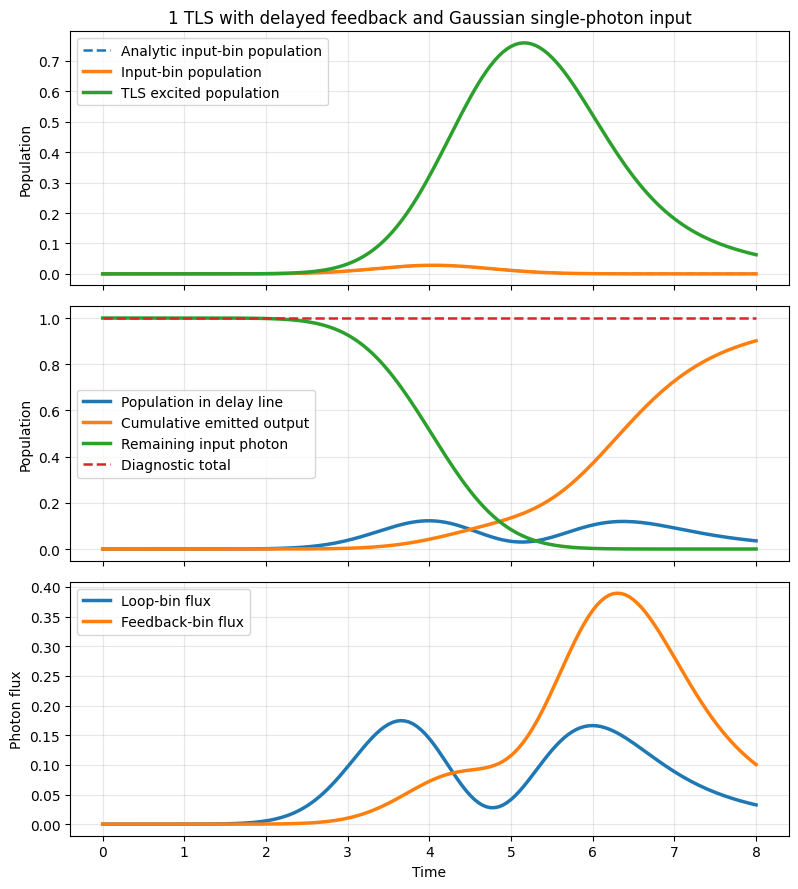

In [2]:
from __future__ import annotations

import time as t

import matplotlib.pyplot as plt
import numpy as np
import wqedmps as qmps


params = qmps.InputParams(
    delta_t=0.05,
    tmax=8.0,
    tau=0.75,
    d_sys_total=np.array([2]),
    d_t_total=np.array([2]),
    gamma_l=0.5,
    gamma_r=0.5,
    phase=np.pi / 3.0,
    bond_max=18,
    atol=1e-12,
)

sys_initial_state = qmps.tls_ground()

# Pulse parameters for a Gaussian single-photon pulse
pulse_time = params.tmax
photon_num = 1
gaussian_center = 4.0
gaussian_width = 1.0

pulse_envelope = qmps.gaussian_envelope(
    pulse_time, params, gaussian_width, gaussian_center
)
normalized_envelope = qmps.normalize_pulse_envelope(params.delta_t, pulse_envelope)
wg_initial_state = qmps.fock_pulse(
    pulse_envelope,
    pulse_time,
    photon_num,
    params,
    direction="R",
)

start_time = t.time()
Hm = qmps.hamiltonian_1tls_feedback(params)
bins = qmps.t_evol_nmar_seemps(Hm, sys_initial_state, wg_initial_state, params)
runtime = t.time() - start_time

times = np.asarray(bins.times, dtype=float)
tls_pop = np.asarray(
    qmps.single_time_expectation(bins.system_states, qmps.tls_pop(params.d_sys)),
    dtype=float,
)
loop_bin_pop = np.asarray(
    qmps.single_time_expectation(bins.loop_field_states, qmps.num_op(params.d_t)),
    dtype=float,
)
feedback_bin_pop = np.asarray(
    qmps.single_time_expectation(bins.output_field_states, qmps.num_op(params.d_t)),
    dtype=float,
)
input_bin_pop = np.asarray(
    qmps.single_time_expectation(bins.input_field_states, qmps.num_op(params.d_t)),
    dtype=float,
)

delay_total_pop = np.asarray(
    [
        loop_bin_pop[max(0, k - params.delay_steps + 1) : k + 1].sum()
        for k in range(len(loop_bin_pop))
    ],
    dtype=float,
)
emitted_output = np.cumsum(feedback_bin_pop)
remaining_input = np.clip(photon_num - np.cumsum(input_bin_pop), 0.0, None)
total_excitation = tls_pop + delay_total_pop + emitted_output + remaining_input

analytic_input_bin_pop = np.zeros_like(times)
analytic_input_bin_pop[1 : 1 + len(normalized_envelope)] = (
    photon_num * np.abs(normalized_envelope) ** 2 * params.delta_t
)

print(f"runtime = {runtime:.3f} s")
print(
    f"max |total_excitation - {photon_num}| = "
    f"{np.max(np.abs(total_excitation - photon_num)):.3e}"
)

fig, axes = plt.subplots(3, 1, figsize=(8.0, 9.0), sharex=True)

axes[0].plot(
    times,
    analytic_input_bin_pop,
    "--",
    lw=1.8,
    label="Analytic input-bin population",
)
axes[0].plot(times, input_bin_pop, lw=2.5, label="Input-bin population")
axes[0].plot(times, tls_pop, lw=2.5, label="TLS excited population")
axes[0].set_ylabel("Population")
axes[0].set_title("1 TLS with delayed feedback and Gaussian single-photon input")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(times, delay_total_pop, lw=2.5, label="Population in delay line")
axes[1].plot(times, emitted_output, lw=2.5, label="Cumulative emitted output")
axes[1].plot(times, remaining_input, lw=2.5, label="Remaining input photon")
axes[1].plot(times, total_excitation, "--", lw=1.8, label="Diagnostic total")
axes[1].set_ylabel("Population")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(times, loop_bin_pop / params.delta_t, lw=2.5, label="Loop-bin flux")
axes[2].plot(
    times,
    feedback_bin_pop / params.delta_t,
    lw=2.5,
    label="Feedback-bin flux",
)
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Photon flux")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
